# Correlation Matrix and Graph Construction

## Correlation Matrix C:
$C_{ij} = Corr(R_i, R_j)$

## Graph G = (V,E):
- Nodes: $V = \{1,...,N\}$
- Edge weights: $w_{ij} = exp(-\frac{1-C_{ij}}{\sigma^2})$
where $\sigma$ is a scaling parameter that controls how quickly the weights decay with decreasing correlation

## Graph Matrices:
- Adjacency matrix W
- Degree matrix D: $D_{ii} = \sum_j w_{ij}$
- Laplacian: $L = D - W$

## Normalized Laplacian:
$\mathcal{L} = I - D^{-1/2}WD^{-1/2}$

Using the log return matrix R from test1.ipynb as input.

In [5]:
import pandas as pd
log_return_matrix = pd.read_csv('/Users/dhairya/cs projects/DS303 final project/dataset/log_returns_matrix.csv')
log_return_matrix.index = log_return_matrix['Date']
log_return_matrix = log_return_matrix.drop('Date', axis=1)

In [6]:
log_return_matrix

,20MICRONS_log_return,3MINDIA_log_return,5PAISA_log_return,63MOONS_log_return,A2ZINFRA_log_return,AARTIDRUGS_log_return,AARVEEDEN_log_return,AAVAS_log_return,ABB_log_return,ABBOTINDIA_log_return,...,ZEELEARN_log_return,ZEEMEDIA_log_return,ZENSARTECH_log_return,ZENTEC_log_return,ZODIAC_log_return,ZODIACLOTH_log_return,ZOTA_log_return,ZUARI_log_return,ZUARIGLOB_log_return,ZYDUSWELL_log_return
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,-0.007008,-0.015814,0.027833,-0.000906,0.056441,-0.002842,0.028371,0.009451,0.003251,-0.000008,...,0.026457,0.000000,0.027553,0.022969,0.002907,0.002907,0.007400,0.182322,0.182322,0.005341
2020-01-06,-0.066347,-0.011604,-0.069245,-0.068161,-0.042560,-0.011109,0.014235,-0.024666,-0.027021,-0.035961,...,-0.030382,-0.025106,-0.048280,-0.050558,-0.019251,-0.019251,-0.024187,-0.083675,-0.083675,-0.007620
2020-01-07,0.012121,0.026701,0.033270,0.033502,0.018462,0.019309,-0.014235,-0.009796,0.015229,-0.002931,...,0.027885,0.016807,0.011204,0.017988,0.023642,0.023642,0.002955,0.182186,0.182186,-0.006663
2020-01-08,-0.015175,-0.019691,-0.043930,-0.020629,-0.024693,-0.014057,0.000000,-0.016499,0.003018,-0.001229,...,-0.020203,0.000000,-0.000544,-0.011956,-0.008506,-0.008506,-0.004840,-0.014379,-0.014379,0.012660
2020-01-09,0.021181,0.001607,-0.002299,0.021093,-0.006270,0.024679,0.010695,0.020323,0.008660,-0.001195,...,-0.012837,-0.008368,0.005153,0.037931,0.012586,0.012586,-0.000809,-0.050205,-0.050205,0.005652
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-12-27,0.022135,-0.010934,-0.002817,0.048718,0.045315,-0.003436,0.093957,0.009245,-0.022095,0.019927,...,-0.021353,-0.015811,-0.015828,0.001394,0.007104,0.007104,-0.005290,-0.010707,-0.010707,-0.007046
2021-12-28,0.045365,0.000240,0.000245,0.048756,0.043350,-0.007389,0.047903,0.000743,0.005270,0.013550,...,0.010734,0.046701,0.059059,0.006712,0.017310,0.017310,0.005415,0.039306,0.039306,0.032194
2021-12-29,-0.002514,-0.000775,-0.005411,0.048681,0.047346,0.018323,-0.051293,0.024102,0.008796,0.013866,...,-0.007143,-0.015326,0.050631,-0.006248,-0.007449,-0.007449,-0.006173,0.017687,0.017687,-0.009048


In [7]:
corr_matrix = log_return_matrix.corr()

In [8]:
corr_matrix

,20MICRONS_log_return,3MINDIA_log_return,5PAISA_log_return,63MOONS_log_return,A2ZINFRA_log_return,AARTIDRUGS_log_return,AARVEEDEN_log_return,AAVAS_log_return,ABB_log_return,ABBOTINDIA_log_return,...,ZEELEARN_log_return,ZEEMEDIA_log_return,ZENSARTECH_log_return,ZENTEC_log_return,ZODIAC_log_return,ZODIACLOTH_log_return,ZOTA_log_return,ZUARI_log_return,ZUARIGLOB_log_return,ZYDUSWELL_log_return
20MICRONS_log_return,1.000000,0.256025,0.167480,0.245571,0.279525,0.226078,0.210094,0.288141,0.234575,0.194677,...,0.217483,0.197470,0.314431,0.210384,0.410000,0.410000,0.159702,0.243773,0.243773,0.117000
3MINDIA_log_return,0.256025,1.000000,0.220083,0.182195,0.224225,0.284786,0.114257,0.275484,0.249044,0.219381,...,0.166100,0.134567,0.264948,0.183711,0.175942,0.175942,0.170769,0.236419,0.236419,0.133160
5PAISA_log_return,0.167480,0.220083,1.000000,0.260224,0.299865,0.244792,0.137364,0.230887,0.225875,0.161127,...,0.177536,0.160941,0.193343,0.143571,0.298646,0.298646,0.178495,0.256262,0.256262,0.098669
63MOONS_log_return,0.245571,0.182195,0.260224,1.000000,0.207133,0.179021,0.151150,0.235900,0.233022,0.112611,...,0.214367,0.197715,0.287155,0.245511,0.281761,0.281761,0.237613,0.233949,0.233949,0.134929
A2ZINFRA_log_return,0.279525,0.224225,0.299865,0.207133,1.000000,0.194304,0.221309,0.191325,0.202040,0.105987,...,0.274396,0.185711,0.162591,0.149353,0.313506,0.313506,0.186241,0.274895,0.274895,0.048532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZODIACLOTH_log_return,0.410000,0.175942,0.298646,0.281761,0.313506,0.193307,0.250884,0.279027,0.322172,0.125749,...,0.296964,0.255309,0.250455,0.206745,1.000000,1.000000,0.183801,0.205411,0.205411,0.120827
ZOTA_log_return,0.159702,0.170769,0.178495,0.237613,0.186241,0.117223,0.085500,0.102542,0.115151,0.145745,...,0.180087,0.149024,0.183383,0.148761,0.183801,0.183801,1.000000,0.141938,0.141938,0.137890
ZUARI_log_return,0.243773,0.236419,0.256262,0.233949,0.274895,0.191132,0.239915,0.214853,0.171910,0.152746,...,0.189151,0.187587,0.266429,0.254448,0.205411,0.205411,0.141938,1.000000,1.000000,0.122220
ZUARIGLOB_log_return,0.243773,0.236419,0.256262,0.233949,0.274895,0.191132,0.239915,0.214853,0.171910,0.152746,...,0.189151,0.187587,0.266429,0.254448,0.205411,0.205411,0.141938,1.000000,1.000000,0.122220


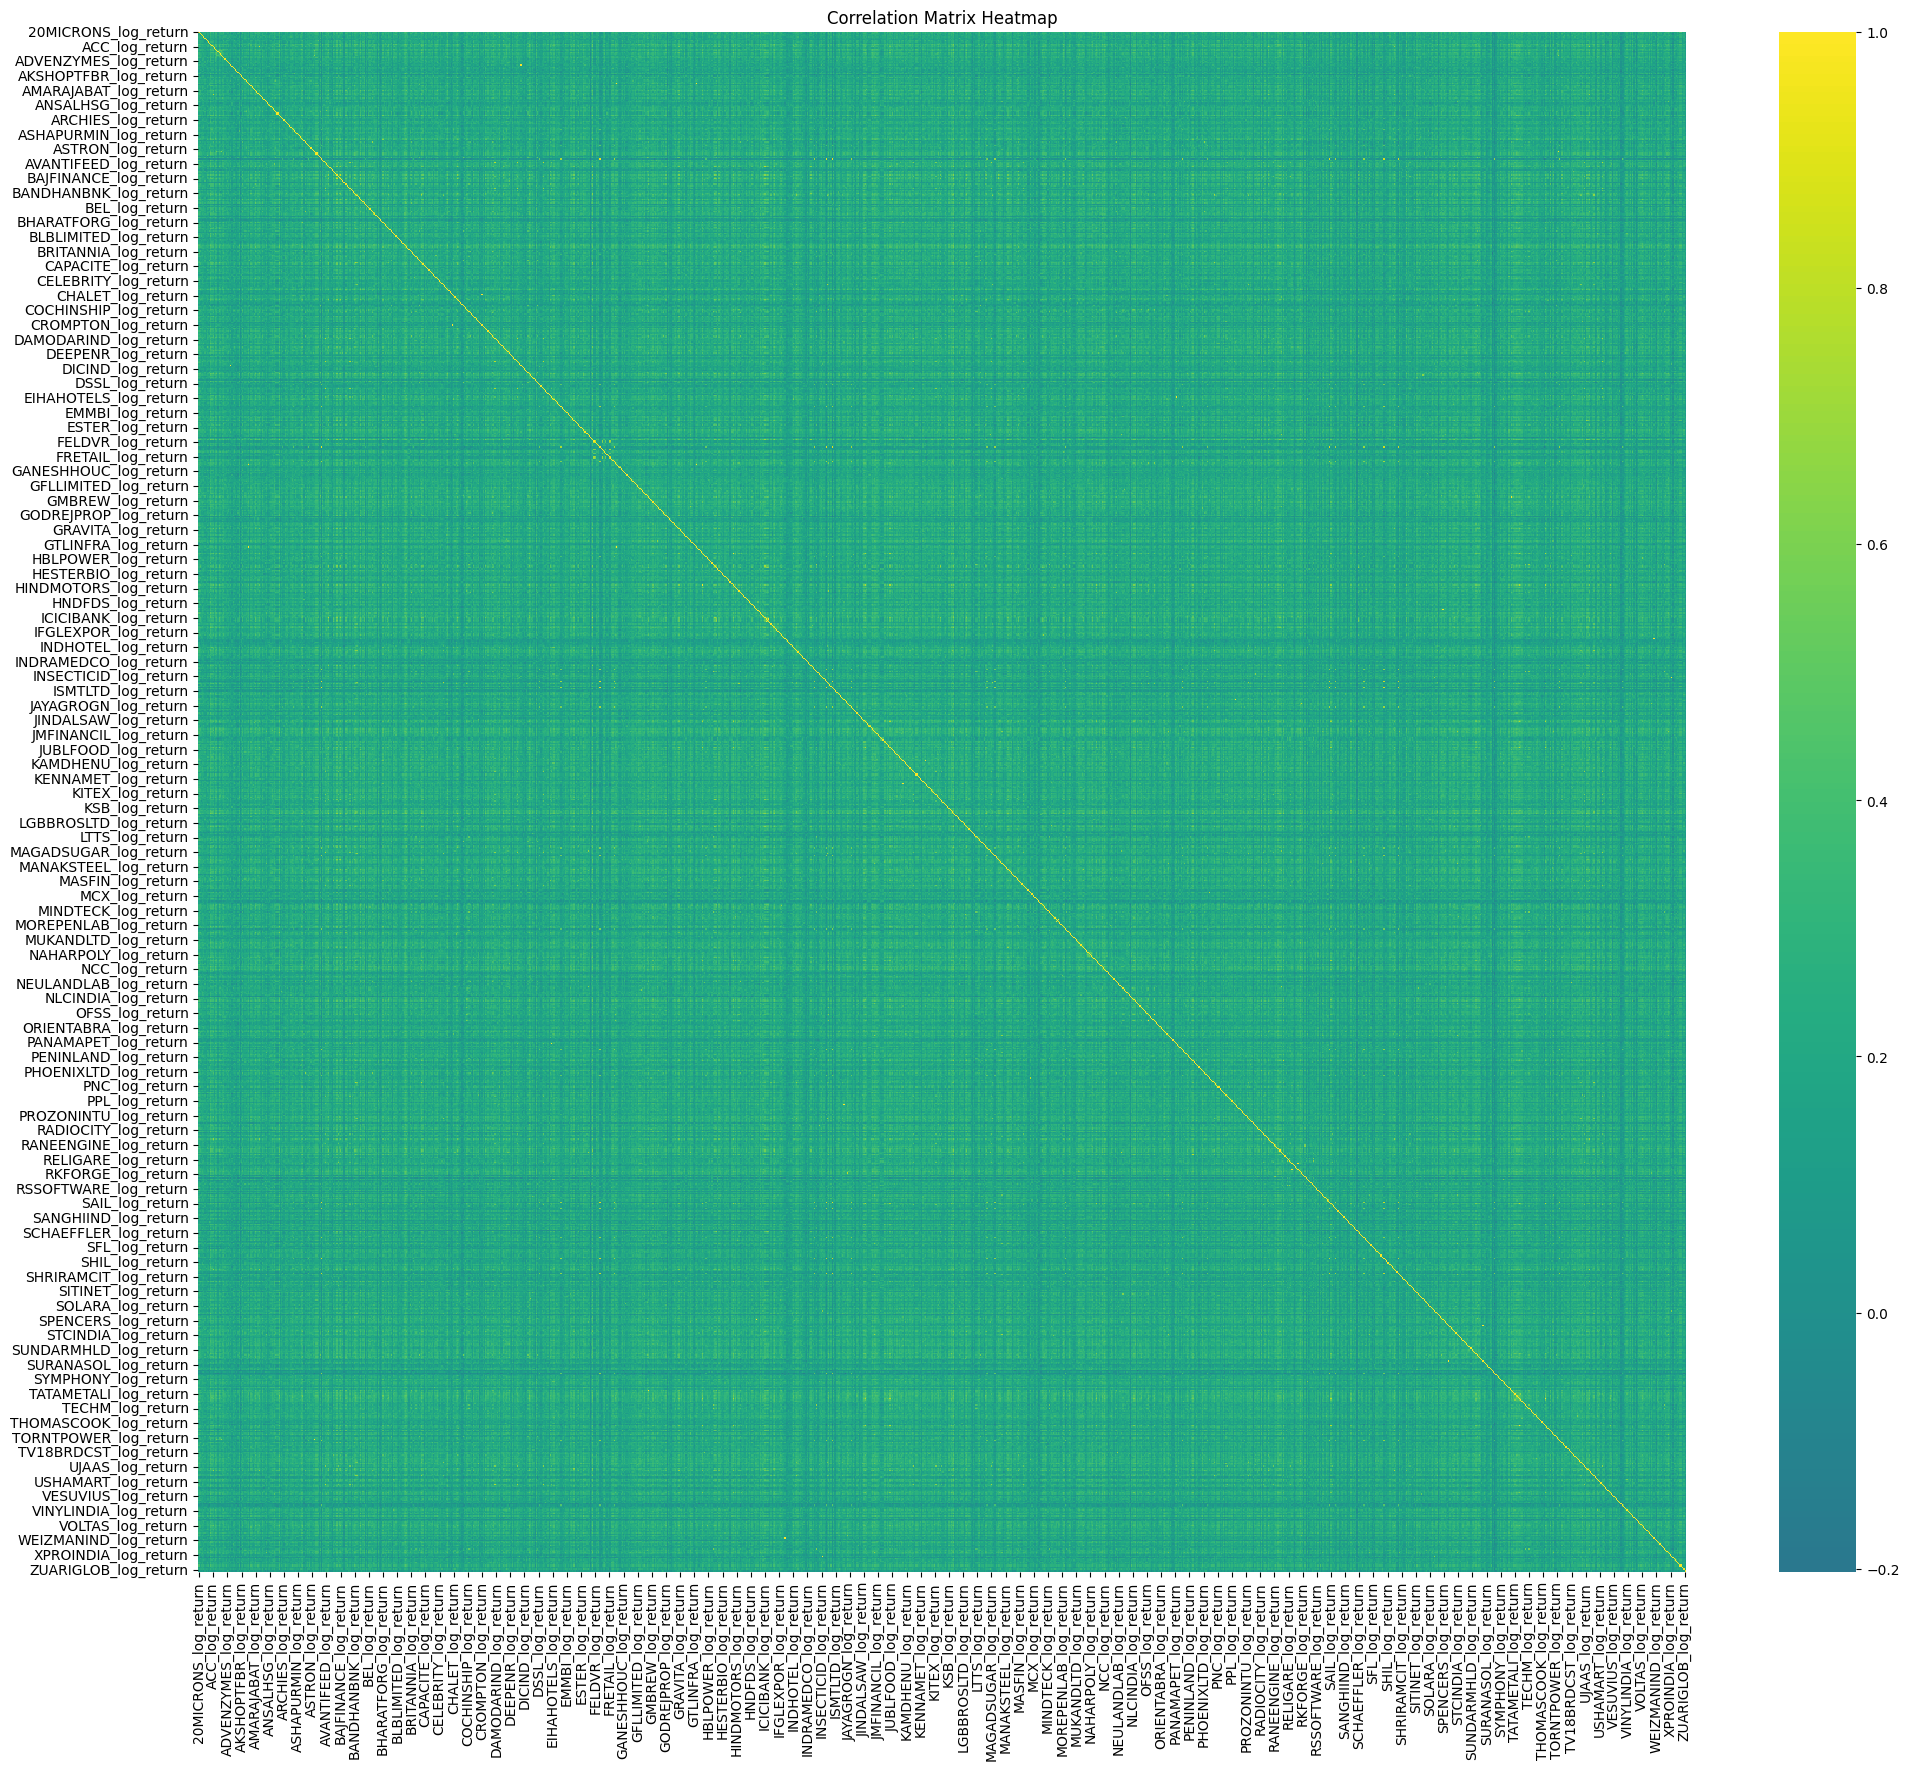

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(24,20))
sns.heatmap(corr_matrix, cmap='viridis', center=0)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [12]:
import numpy as np
def create_adjacency_matrix(corr_matrix, sigma):    
    C = corr_matrix.values
    W = np.exp(-(1 - C)/(sigma**2))
    return pd.DataFrame(W, index=corr_matrix.index, columns=corr_matrix.columns)

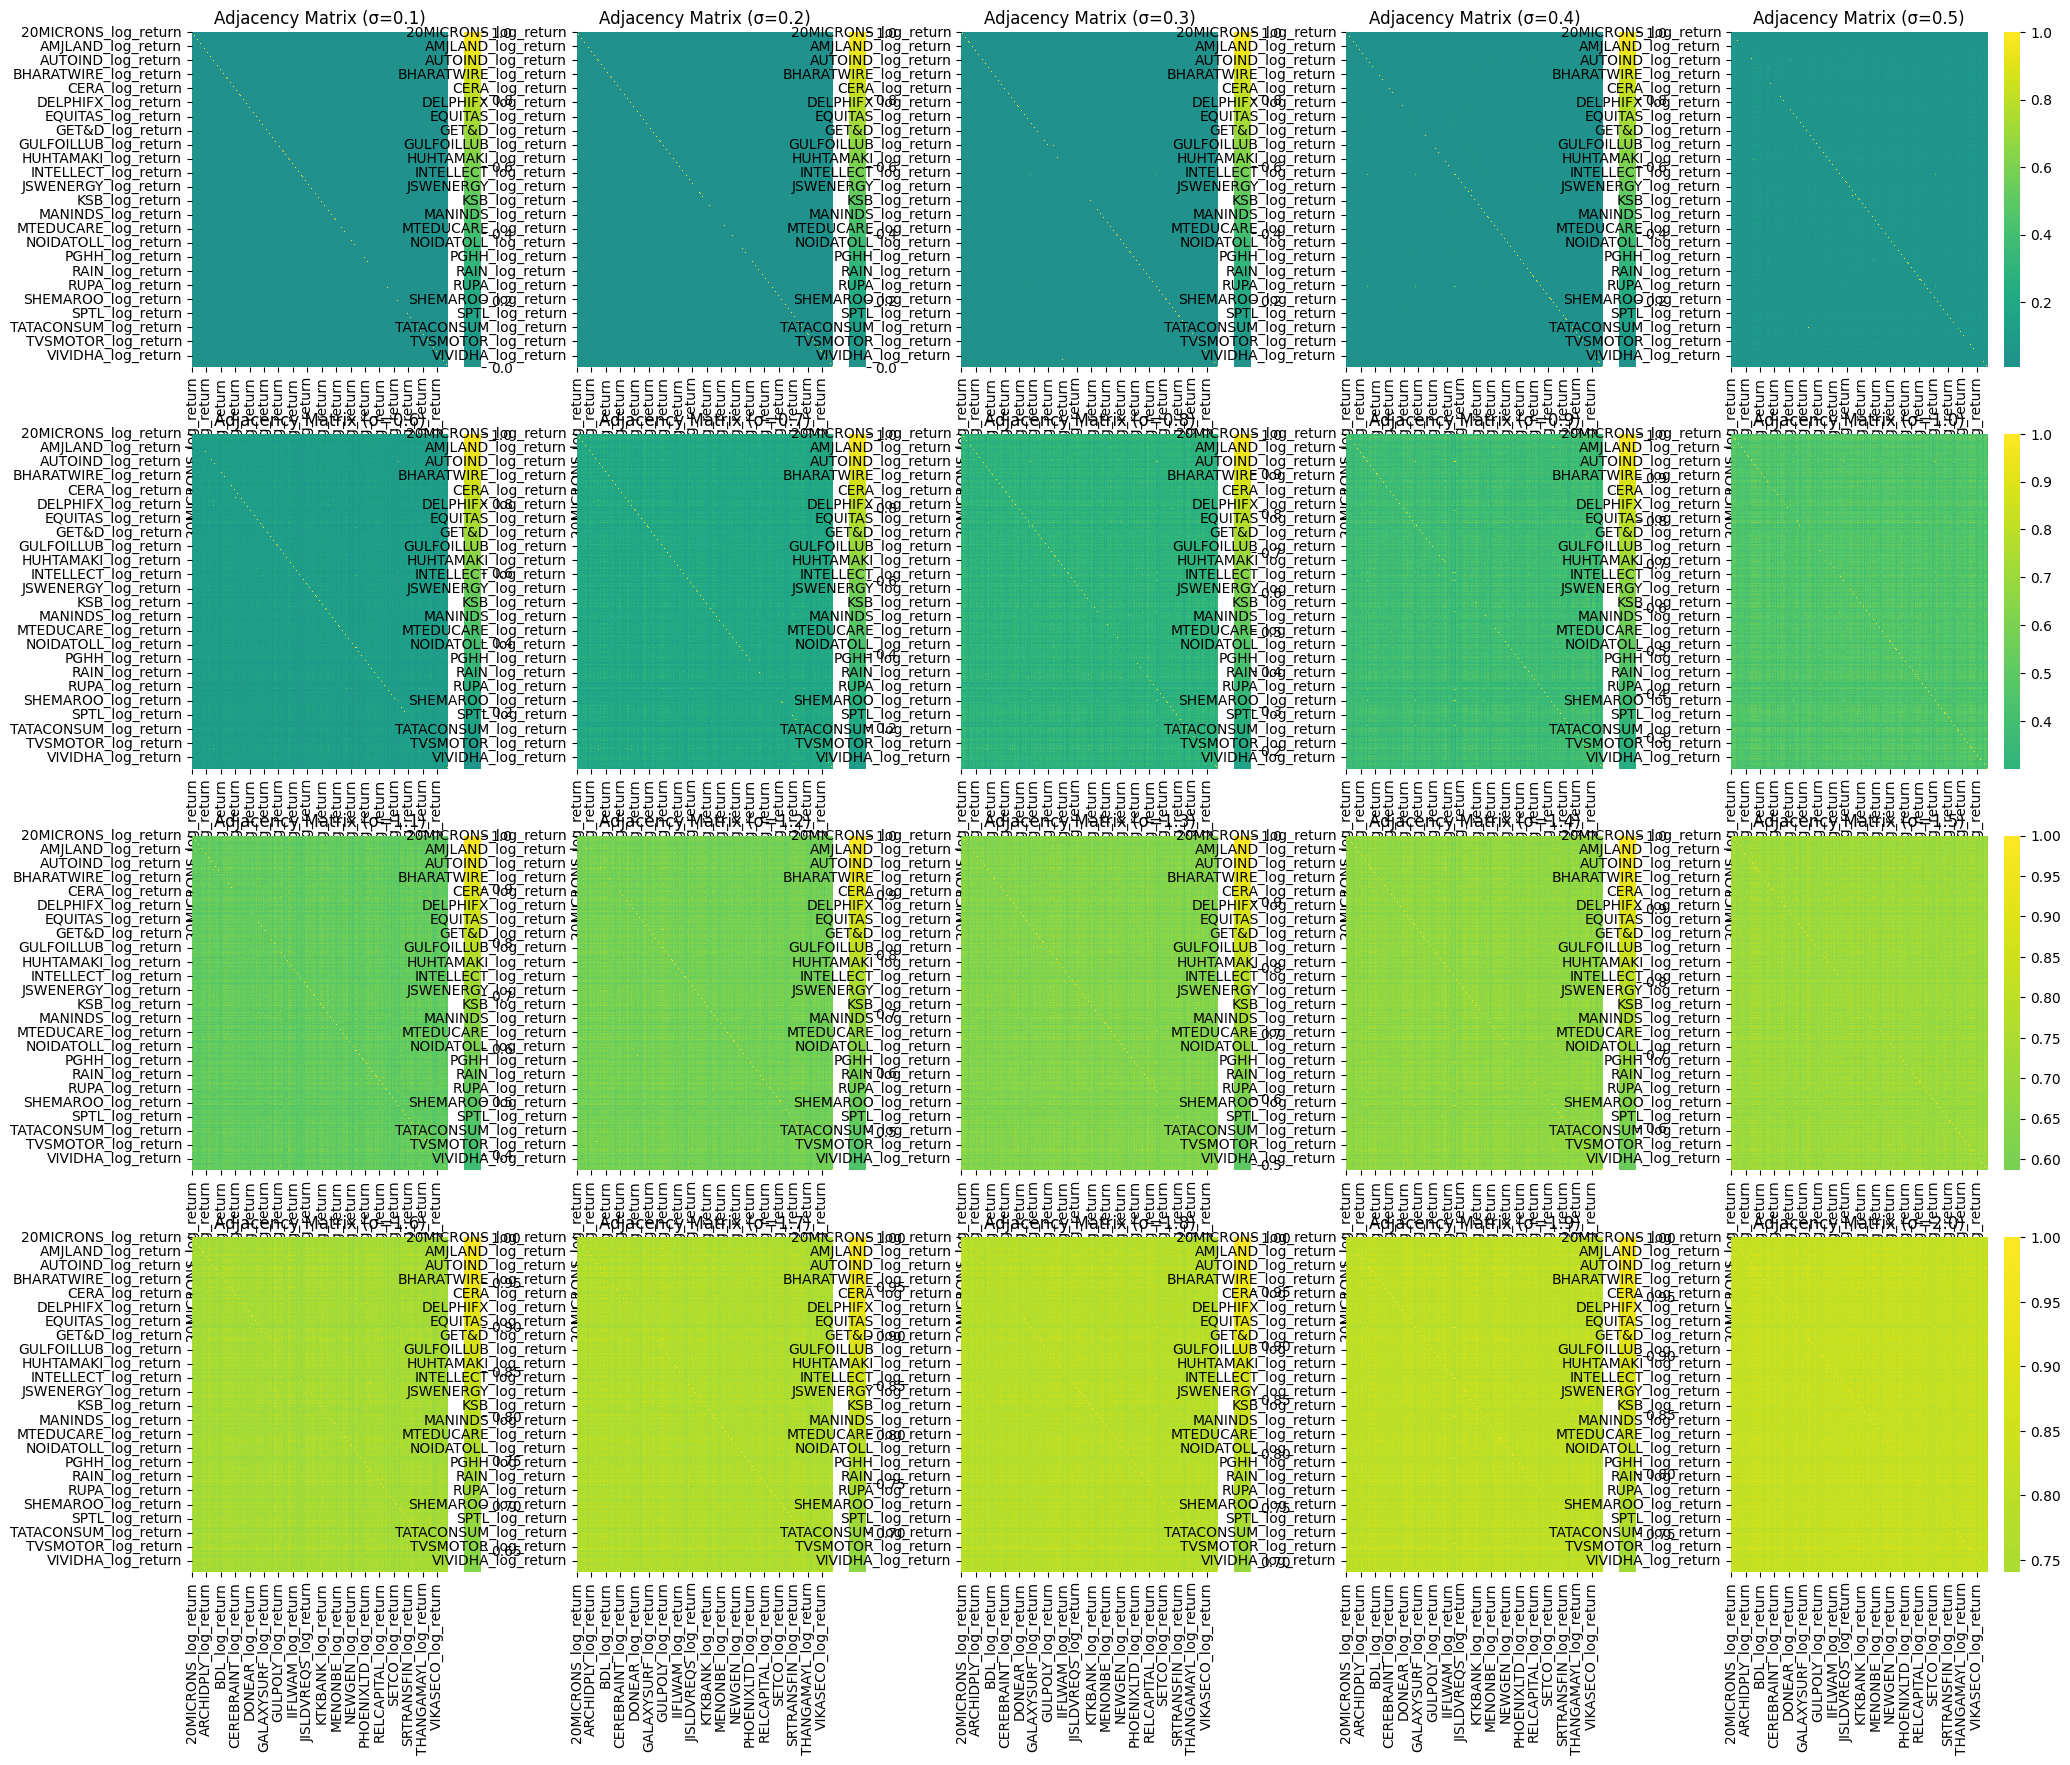

In [23]:
sigma_values = np.arange(0.1, 2.1, 0.1)
n_rows = 4
n_cols = 5

plt.figure(figsize=(24, 20))

for i, sigma in enumerate(sigma_values):
    adj_matrix = create_adjacency_matrix(corr_matrix, sigma)
    
    plt.subplot(n_rows, n_cols, i+1)
    sns.heatmap(adj_matrix, cmap='viridis', center=0)
    plt.title(f'Adjacency Matrix (σ={sigma:.1f})')

Here from above we can see that sigma = 0.8 seems most optimum

In [26]:
W = create_adjacency_matrix(corr_matrix, 0.8)
D = np.diag(np.sum(W, axis=1))

In [31]:
D_inv_sqrt = np.diag(1/np.sqrt(np.diag(D)))
L = np.eye(len(D)) - D_inv_sqrt @ W @ D_inv_sqrt

In [36]:
L.index = corr_matrix.index
L.columns = corr_matrix.columns
L

,20MICRONS_log_return,3MINDIA_log_return,5PAISA_log_return,63MOONS_log_return,A2ZINFRA_log_return,AARTIDRUGS_log_return,AARVEEDEN_log_return,AAVAS_log_return,ABB_log_return,ABBOTINDIA_log_return,...,ZEELEARN_log_return,ZEEMEDIA_log_return,ZENSARTECH_log_return,ZENTEC_log_return,ZODIAC_log_return,ZODIACLOTH_log_return,ZOTA_log_return,ZUARI_log_return,ZUARIGLOB_log_return,ZYDUSWELL_log_return
20MICRONS_log_return,0.997491,-0.000806,-0.000717,-0.000795,-0.000846,-0.000790,-0.000787,-0.000854,-0.000795,-0.000767,...,-0.000777,-0.000766,-0.000895,-0.000770,-0.000994,-0.000994,-0.000731,-0.000792,-0.000792,-0.000704
3MINDIA_log_return,-0.000806,0.997355,-0.000799,-0.000739,-0.000797,-0.000890,-0.000696,-0.000860,-0.000835,-0.000818,...,-0.000737,-0.000713,-0.000851,-0.000758,-0.000708,-0.000708,-0.000764,-0.000804,-0.000804,-0.000741
5PAISA_log_return,-0.000717,-0.000799,0.997240,-0.000853,-0.000917,-0.000854,-0.000737,-0.000819,-0.000822,-0.000763,...,-0.000766,-0.000759,-0.000777,-0.000727,-0.000876,-0.000876,-0.000790,-0.000848,-0.000848,-0.000717
63MOONS_log_return,-0.000795,-0.000739,-0.000853,0.997340,-0.000778,-0.000756,-0.000739,-0.000810,-0.000816,-0.000695,...,-0.000797,-0.000789,-0.000883,-0.000837,-0.000838,-0.000838,-0.000851,-0.000804,-0.000804,-0.000745
A2ZINFRA_log_return,-0.000846,-0.000797,-0.000917,-0.000778,0.997286,-0.000782,-0.000833,-0.000763,-0.000785,-0.000694,...,-0.000884,-0.000782,-0.000734,-0.000728,-0.000889,-0.000889,-0.000793,-0.000865,-0.000865,-0.000658
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZODIACLOTH_log_return,-0.000994,-0.000708,-0.000876,-0.000838,-0.000889,-0.000748,-0.000836,-0.000839,-0.000908,-0.000686,...,-0.000877,-0.000835,-0.000807,-0.000763,-0.002491,0.997509,-0.000757,-0.000744,-0.000744,-0.000705
ZOTA_log_return,-0.000731,-0.000764,-0.000790,-0.000851,-0.000793,-0.000723,-0.000702,-0.000692,-0.000715,-0.000770,...,-0.000795,-0.000769,-0.000790,-0.000758,-0.000757,-0.000757,0.997054,-0.000732,-0.000732,-0.000788
ZUARI_log_return,-0.000792,-0.000804,-0.000848,-0.000804,-0.000865,-0.000771,-0.000849,-0.000784,-0.000742,-0.000740,...,-0.000766,-0.000776,-0.000855,-0.000849,-0.000744,-0.000744,-0.000732,0.997340,-0.002660,-0.000731
ZUARIGLOB_log_return,-0.000792,-0.000804,-0.000848,-0.000804,-0.000865,-0.000771,-0.000849,-0.000784,-0.000742,-0.000740,...,-0.000766,-0.000776,-0.000855,-0.000849,-0.000744,-0.000744,-0.000732,-0.002660,0.997340,-0.000731


In [37]:
L.to_csv('/Users/dhairya/cs projects/DS303 final project/dataset/laplacian_matrix.csv')

In [40]:
def L_given_sigma(sigma):
    W = create_adjacency_matrix(corr_matrix, sigma)
    D = np.diag(np.sum(W, axis=1))
    D_inv_sqrt = np.diag(1/np.sqrt(np.diag(D)))
    L = np.eye(len(D)) - D_inv_sqrt @ W @ D_inv_sqrt
    L.index = corr_matrix.index
    L.columns = corr_matrix.columns
    return L
    


In [41]:
L_given_sigma(0.2)

,20MICRONS_log_return,3MINDIA_log_return,5PAISA_log_return,63MOONS_log_return,A2ZINFRA_log_return,AARTIDRUGS_log_return,AARVEEDEN_log_return,AAVAS_log_return,ABB_log_return,ABBOTINDIA_log_return,...,ZEELEARN_log_return,ZEEMEDIA_log_return,ZENSARTECH_log_return,ZENTEC_log_return,ZODIAC_log_return,ZODIACLOTH_log_return,ZOTA_log_return,ZUARI_log_return,ZUARIGLOB_log_return,ZYDUSWELL_log_return
20MICRONS_log_return,3.921214e-05,-8.363265e-09,-9.141452e-10,-6.439940e-09,-1.504967e-08,-3.955812e-09,-2.652746e-09,-1.866697e-08,-4.892084e-09,-1.804312e-09,...,-3.190959e-09,-1.934779e-09,-3.601795e-08,-2.672062e-09,-2.777313e-07,-2.777313e-07,-7.526186e-10,-4.353584e-09,-4.353584e-09,-2.587883e-10
3MINDIA_log_return,-8.363265e-09,2.508934e-05,-3.405276e-09,-1.320650e-09,-3.776768e-09,-1.716568e-08,-2.416335e-10,-1.360376e-08,-7.024145e-09,-3.346032e-09,...,-8.831618e-10,-4.014850e-10,-1.045350e-08,-1.371655e-09,-7.986889e-10,-7.986889e-10,-9.925164e-10,-3.622469e-09,-3.622469e-09,-3.876094e-10
5PAISA_log_return,-9.141452e-10,-3.405276e-09,6.427405e-06,-9.289292e-09,-2.502516e-08,-6.315856e-09,-4.305750e-10,-4.461194e-09,-3.935877e-09,-7.799145e-10,...,-1.175457e-09,-7.763042e-10,-1.745129e-09,-5.028490e-10,-1.716430e-08,-1.716430e-08,-1.203979e-09,-5.949146e-09,-5.949146e-09,-1.636541e-10
63MOONS_log_return,-6.439940e-09,-1.320650e-09,-9.289292e-09,1.078128e-05,-2.463504e-09,-1.219905e-09,-6.077511e-10,-5.056927e-09,-4.705842e-09,-2.318947e-10,...,-2.951871e-09,-1.946719e-09,-1.821300e-08,-6.430390e-09,-1.125364e-08,-1.125364e-08,-5.278163e-09,-3.405537e-09,-3.405537e-09,-4.051455e-10
A2ZINFRA_log_return,-1.504967e-08,-3.776768e-09,-2.502516e-08,-2.463504e-09,7.840975e-06,-1.787578e-09,-3.511277e-09,-1.659251e-09,-2.168978e-09,-1.965044e-10,...,-1.323889e-08,-1.442016e-09,-8.089824e-10,-5.810554e-10,-2.488673e-08,-2.488673e-08,-1.461249e-09,-9.478844e-09,-9.478844e-09,-4.672708e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZODIACLOTH_log_return,-2.777313e-07,-7.986889e-10,-1.716430e-08,-1.125364e-08,-2.488673e-08,-1.232875e-09,-5.200580e-09,-1.051031e-08,-3.090703e-08,-2.277308e-10,...,-1.645740e-08,-5.808973e-09,-5.145089e-09,-1.725130e-09,-4.999877e-01,5.000123e-01,-9.721072e-10,-1.179832e-09,-1.179832e-09,-2.013650e-10
ZOTA_log_return,-7.526186e-10,-9.925164e-10,-1.203979e-09,-5.278163e-09,-1.461249e-09,-2.602387e-10,-1.177440e-10,-1.802896e-10,-2.471004e-10,-5.309313e-10,...,-1.252866e-09,-5.762961e-10,-1.360484e-09,-5.725196e-10,-9.721072e-10,-9.721072e-10,1.909957e-06,-3.413451e-10,-3.413451e-10,-4.362714e-10
ZUARI_log_return,-4.353584e-09,-3.622469e-09,-5.949146e-09,-3.405537e-09,-9.478844e-09,-1.167650e-09,-3.953329e-09,-2.112783e-09,-7.221143e-10,-4.472365e-10,...,-1.111215e-09,-1.068622e-09,-7.670667e-09,-5.685358e-09,-1.179832e-09,-1.179832e-09,-3.413451e-10,5.000032e-01,-4.999968e-01,-2.085030e-10
ZUARIGLOB_log_return,-4.353584e-09,-3.622469e-09,-5.949146e-09,-3.405537e-09,-9.478844e-09,-1.167650e-09,-3.953329e-09,-2.112783e-09,-7.221143e-10,-4.472365e-10,...,-1.111215e-09,-1.068622e-09,-7.670667e-09,-5.685358e-09,-1.179832e-09,-1.179832e-09,-3.413451e-10,-4.999968e-01,5.000032e-01,-2.085030e-10


# Spectral Clustering

Let L be the normalized Laplacian matrix computed in test2.ipynb.

For k clusters, we:

1. Find the k smallest eigenvectors of L:
   U = [u₁, u₂, ..., uₖ] ∈ ℝⁿˣᵏ 
   where uᵢ is the i-th eigenvector

2. Normalize each row i of U:
   ũᵢ = Uᵢ/||Uᵢ||
   where ||Uᵢ|| is the L2 norm of row i

3. Apply k-means clustering to the normalized rows ũᵢ:
   Each stock i is assigned to a cluster c(i) ∈ {1,...,k}


In [42]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.sparse.linalg import eigsh
from typing import Tuple, Dict

def spectral_clustering(L: pd.DataFrame, k: int) -> Dict[str, any]:
    print("[INFO] Computing smallest eigenvectors...")
    eigenvalues, eigenvectors = eigsh(L.values, k=k, which='SM')  # Smallest magnitude eigenvalues

    print("[INFO] Normalizing eigenvector rows...")
    row_norms = np.linalg.norm(eigenvectors, axis=1, keepdims=True)
    row_norms[row_norms == 0] = 1e-10  # Avoid division by zero
    U_normalized = eigenvectors / row_norms

    print(f"[INFO] Applying KMeans with k={k}...")
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    cluster_labels = kmeans.fit_predict(U_normalized)

    print("[INFO] Evaluating clustering quality...")
    silhouette = silhouette_score(U_normalized, cluster_labels)
    calinski = calinski_harabasz_score(U_normalized, cluster_labels)
    davies = davies_bouldin_score(U_normalized, cluster_labels)

    stock_names = list(L.columns)
    clusters = {stock: int(cluster) for stock, cluster in zip(stock_names, cluster_labels)}

    result = {
        'clusters': clusters,
        'silhouette_score': silhouette,
        'calinski_harabasz_score': calinski,
        'davies_bouldin_score': davies
    }

    print("[INFO] Spectral clustering completed successfully.")
    return result

In [70]:
def optimize_clustering(k_range=(5,8), sigma_range=(0.5,3,0.1)) -> Dict[str, any]:
    print("[INFO] Starting optimization...")
    
    best_scores = {
        'silhouette': -1,
        'calinski': -1, 
        'davies': float('inf'),
        'k': None,
        'sigma': None,
        'clusters': None
    }

    for k in range(k_range[0], k_range[1]+1):
        for sigma in np.arange(sigma_range[0], sigma_range[1], 0.1):
            print(f"[INFO] Testing k={k}, sigma={sigma:.2f}")
            
            try:
                L = L_given_sigma(sigma)
                result = spectral_clustering(L, k)
                
                if (result['calinski_harabasz_score'] > best_scores['calinski'] ):
                    
                    best_scores['silhouette'] = result['silhouette_score']
                    best_scores['calinski'] = result['calinski_harabasz_score']
                    best_scores['davies'] = result['davies_bouldin_score']
                    best_scores['k'] = k
                    best_scores['sigma'] = sigma
                    best_scores['clusters'] = result['clusters']
            
            except Exception as e:
                print(f"[WARNING] Error occurred for k={k}, sigma={sigma:.2f}: {str(e)}. Skipping...")
                continue
                
    print("\n[INFO] Optimization completed.")
    print(f"Best parameters found:")
    print(f"k = {best_scores['k']}")
    print(f"sigma = {best_scores['sigma']:.2f}")
    print(f"Silhouette Score: {best_scores['silhouette']:.4f}")
    print(f"Calinski-Harabasz Score: {best_scores['calinski']:.4f}")
    print(f"Davies-Bouldin Score: {best_scores['davies']:.4f}")
    
    return best_scores

In [71]:
best_scores = optimize_clustering()

[INFO] Starting optimization...
[INFO] Testing k=5, sigma=0.50
[INFO] Computing smallest eigenvectors...
[INFO] Normalizing eigenvector rows...
[INFO] Applying KMeans with k=5...
[INFO] Evaluating clustering quality...
[INFO] Spectral clustering completed successfully.
[INFO] Testing k=5, sigma=0.60
[INFO] Computing smallest eigenvectors...
[INFO] Normalizing eigenvector rows...
[INFO] Applying KMeans with k=5...
[INFO] Evaluating clustering quality...
[INFO] Spectral clustering completed successfully.
[INFO] Testing k=5, sigma=0.70
[INFO] Computing smallest eigenvectors...
[INFO] Normalizing eigenvector rows...
[INFO] Applying KMeans with k=5...
[INFO] Evaluating clustering quality...
[INFO] Spectral clustering completed successfully.
[INFO] Testing k=5, sigma=0.80
[INFO] Computing smallest eigenvectors...
[INFO] Normalizing eigenvector rows...
[INFO] Applying KMeans with k=5...
[INFO] Evaluating clustering quality...
[INFO] Spectral clustering completed successfully.
[INFO] Testing k

Best K = 5, best sigma = 0.6

In [72]:
result = spectral_clustering(L_given_sigma(0.6), 5)

[INFO] Computing smallest eigenvectors...
[INFO] Normalizing eigenvector rows...
[INFO] Applying KMeans with k=5...
[INFO] Evaluating clustering quality...
[INFO] Spectral clustering completed successfully.


In [83]:
df = pd.DataFrame({'Cluster': result['clusters']}).reset_index()
df.columns = ['Stock', 'Cluster'] 


In [85]:
df.to_csv('/Users/dhairya/cs projects/DS303 final project/dataset/spectral_clustering_clusters.csv', index=False)

In [86]:
df

,Stock,Cluster
0,20MICRONS_log_return,0
1,3MINDIA_log_return,2
2,5PAISA_log_return,3
3,63MOONS_log_return,1
4,A2ZINFRA_log_return,1
...,...,...
1257,ZODIACLOTH_log_return,4
1258,ZOTA_log_return,3
1259,ZUARI_log_return,0
1260,ZUARIGLOB_log_return,0
